# Baseline Approaches


How does our ML-based downscaling results compare to regular interpolation methods (using OpenCV) such as:

* Bilinear (```INTER_LINEAR```)
* (```INTER_AREA```)
* Nearest Neighbor (```INTER_NEAREST```)
* Bicubic (```INTER_CUBIC```)

In [1]:
import xarray as xr
import numpy as np
import ecubevis as ecv
import scipy as sp
import netCDF4 as nc
import os
import shutil
import csv
import pandas as pd
import torch_dl4ds as dds
import torch as pt

In [2]:
uwrf_train = xr.open_dataset('/D4/data/gvaillant/uwrf-split/uwrf_train.nc')
uwrf_val = xr.open_dataset('/D4/data/gvaillant/uwrf-split/uwrf_val.nc')
uwrf_test = xr.open_dataset('/D4/data/gvaillant/uwrf-split/uwrf_test.nc')
# --------
nam_train = xr.open_dataset('/D4/data/gvaillant/nam-split/nam_train.nc')
nam_val = xr.open_dataset('/D4/data/gvaillant/nam-split/nam_val.nc')
nam_test = xr.open_dataset('/D4/data/gvaillant/nam-split/nam_test.nc')

In [3]:
# dims: time, y, x
nam = nam_test
uwrf = uwrf_test
print("NAM lat shape:", nam['latitude'].shape)
print("NAM lon shape:", nam['longitude'].shape)
print("uWRF lat shape:", uwrf['latitude'].shape)
print("uWRF lon shape:", uwrf['longitude'].shape)
uwrf

NAM lat shape: (40, 40)
NAM lon shape: (40, 40)
uWRF lat shape: (578, 120, 120)
uWRF lon shape: (578, 120, 120)


<xarray.Dataset> Size: 300MB
Dimensions:    (time: 578, y: 120, x: 120)
Coordinates:
    latitude   (time, y, x) float32 33MB ...
    longitude  (time, y, x) float32 33MB ...
  * time       (time) datetime64[ns] 5kB 2019-05-04T21:00:00 ... 2019-05-29T1...
Dimensions without coordinates: y, x
Data variables:
    T2         (time, y, x) float32 33MB ...
    PSFC       (time, y, x) float32 33MB ...
    U10        (time, y, x) float32 33MB ...
    V10        (time, y, x) float32 33MB ...
    SWDOWN     (time, y, x) float32 33MB ...
    PBLH       (time, y, x) float32 33MB ...
    HGT        (time, y, x) float32 33MB ...
Attributes: (12/119)
    TITLE:                            OUTPUT FROM WRF V3.9 MODEL
    START_DATE:                      2019-01-01_00:00:00
    SIMULATION_START_DATE:           2019-01-01_00:00:00
    WEST-EAST_GRID_DIMENSION:        121
    SOUTH-NORTH_GRID_DIMENSION:      121
    BOTTOM-TOP_GRID_DIMENSION:       51
    ...                              ...
    ISLAKE:                          -1
    ISICE:                           15
    ISURBAN:                         13
    ISOILWATER:                      14
    HYBRID_OPT:                      -1
    ETAC:                            0.0

In [4]:
import cv2
import xarray as xr
import numpy as np

# -- Set the specific time we want to examine -- 
t_idx = 2

# -- Data ---
nam = xr.open_dataset('/D4/data/gvaillant/nam-split/nam_test.nc')
uwrf = xr.open_dataset('/D4/data/gvaillant/uwrf-split/uwrf_test.nc')

lr = nam['T2'].isel(time=t_idx).values

data_min = lr.min()
data_max = lr.max()

image = np.array(lr)
image = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

resized_image = cv2.resize(image, (120, 120), interpolation = cv2.INTER_LINEAR) ## CHANGE INTERPOLATION METHOD HERE 

resized_image_unnorm = resized_image.astype(np.float32) / 255.0  # Scale to 0-1
resized_image_unnorm = resized_image_unnorm * (data_max - data_min) + data_min


# calculate the mae for that one time step: 
uwrf = xr.open_dataset('/D4/data/gvaillant/uwrf-split/uwrf_test.nc')
y_true = uwrf["T2"].isel(time=t_idx).values
y_pred = resized_image_unnorm
og = lr

In [5]:
# Compute MAE in K
mae = np.mean(np.abs(y_pred - y_true))
rmse = np.sqrt(np.mean((y_pred - y_true) ** 2))
# Compute MAPE (in %)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")

MAE: 1.86
RMSE: 2.44
MAPE: 0.65%


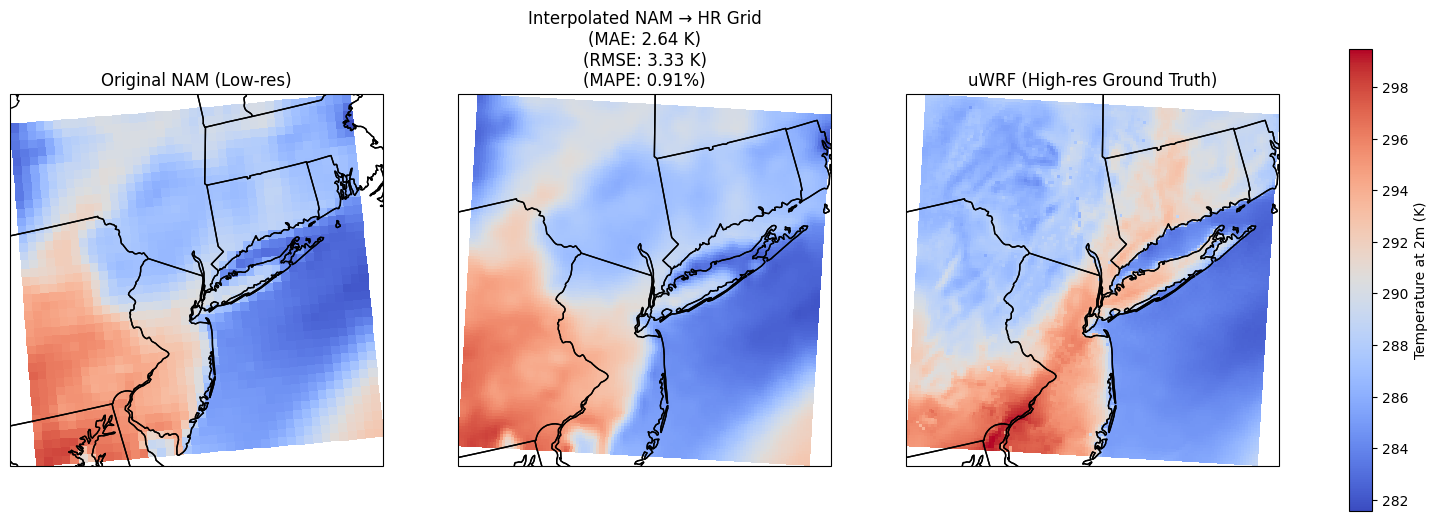

In [6]:
import cv2
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# -- Set the specific time we want to examine -- 
t_idx = 0

# -- Load Data ---
nam = xr.open_dataset('/D4/data/gvaillant/nam-split/nam_test.nc')
uwrf = xr.open_dataset('/D4/data/gvaillant/uwrf-split/uwrf_test.nc')

# Extract slices
lr = nam['T2'].isel(time=t_idx).values      # Low-resolution NAM slice
hr = uwrf['T2'].isel(time=t_idx).values     # High-resolution uWRF slice

# Normalize LR for resizing
data_min, data_max = lr.min(), lr.max()
image = cv2.normalize(lr, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

# Resize (interpolation) and un-normalize
resized_image = cv2.resize(image, (hr.shape[1], hr.shape[0]), interpolation=cv2.INTER_CUBIC)
resized_image_unnorm = resized_image.astype(np.float32) / 255.0 * (data_max - data_min) + data_min

# MAE
mae = np.mean(np.abs(hr - resized_image_unnorm))
#print(f"MAE: {mae:.2f} K")

# MAPE
mape = np.mean(np.abs((hr - resized_image_unnorm) / hr)) * 100
#print(f"MAPE: {mape:.2f}%")

# RMSE
rmse = np.sqrt(np.mean((resized_image_unnorm - hr) ** 2))
#print(f"RMSE: {rmse:.2f} K")


nam_lat = nam.latitude.values
nam_lon = nam.longitude.values

uwrf_lat = uwrf.latitude.isel(time=t_idx).values  # (120,120)
uwrf_lon = uwrf.longitude.isel(time=t_idx).values  # (120,120)

#print("Resized image shape:", resized_image_unnorm.shape)
#print("uWRF lat shape:", uwrf_lat.shape)
#print("uWRF lon shape:", uwrf_lon.shape)


# ---- PLOTTING ----
fig, axes = plt.subplots(1, 3, figsize=(18, 6), subplot_kw={"projection": ccrs.LambertConformal()})

# common color limits
vmin = min(lr.min(), hr.min())
vmax = max(lr.max(), hr.max())

# Plot original NAM (Low-res)
axes[0].pcolormesh(nam_lon, nam_lat, lr, transform=ccrs.PlateCarree(), vmin=vmin, vmax=vmax, cmap='coolwarm')
axes[0].set_title("Original NAM (Low-res)")
axes[0].coastlines()
axes[0].add_feature(cfeature.STATES)

# Plot Interpolated NAM (Resized to HR)
axes[1].pcolormesh(uwrf_lon, uwrf_lat, resized_image_unnorm, transform=ccrs.PlateCarree(), vmin=vmin, vmax=vmax, cmap='coolwarm')
axes[1].set_title(f"Interpolated NAM → HR Grid\n(MAE: {mae:.2f} K)\n(RMSE: {rmse:.2f} K)\n(MAPE: {mape:.2f}%)")
axes[1].coastlines()
axes[1].add_feature(cfeature.STATES)

# Plot uWRF (High-res ground truth)
im2 = axes[2].pcolormesh(uwrf_lon, uwrf_lat, hr, transform=ccrs.PlateCarree(), vmin=vmin, vmax=vmax, cmap='coolwarm')
axes[2].set_title("uWRF (High-res Ground Truth)")
axes[2].coastlines()
axes[2].add_feature(cfeature.STATES)

#Single shared colorbar
cbar = fig.colorbar(im2, ax=axes, orientation='vertical', fraction=0.04, pad=0.05)
cbar.set_label('Temperature at 2m (K)')


#plt.tight_layout()
plt.show()


In [8]:
from scipy.interpolate import griddata
import numpy as np
from skimage.metrics import structural_similarity as ssim
# Define methods to test
interp_methods = ['nearest', 'linear', 'cubic']
results = {}

# Flatten input grid
nam_points = np.column_stack((nam_lat.flatten(), nam_lon.flatten()))
nam_values = lr.flatten()
target_points = np.column_stack((uwrf_lat.flatten(), uwrf_lon.flatten()))

# Loop through interpolation methods
for method in interp_methods:
    print(f"Interpolating with method: {method}")
    interp_flat = griddata(nam_points, nam_values, target_points, method=method)
    
    # Reshape to 2D
    interp_2d = interp_flat.reshape(uwrf_lat.shape)
    
    # Normalize to [0, 1] for SSIM
    hr_norm = (hr - hr.min()) / (hr.max() - hr.min())
    interp_norm = (interp_2d - hr.min()) / (hr.max() - hr.min())
    
    
    # Evaluate error metrics
    mae = np.mean(np.abs(interp_2d - hr))
    rmse = np.sqrt(np.mean((interp_2d - hr) ** 2))
    hr_safe = np.where(np.abs(hr) < 1e-3, 1e-3, hr)  # For safe MAPE
    mape = np.mean(np.abs((interp_2d - hr) / hr_safe)) * 100
    ssim_val = ssim(hr_norm, interp_norm, data_range=1.0)

    # Store results
    results[method] = {
        'interpolated': interp_2d,
        'mae': mae,
        'rmse': rmse,
        'mape': mape,
        'ssim': ssim_val
    }


Interpolating with method: nearest
Interpolating with method: linear
Interpolating with method: cubic


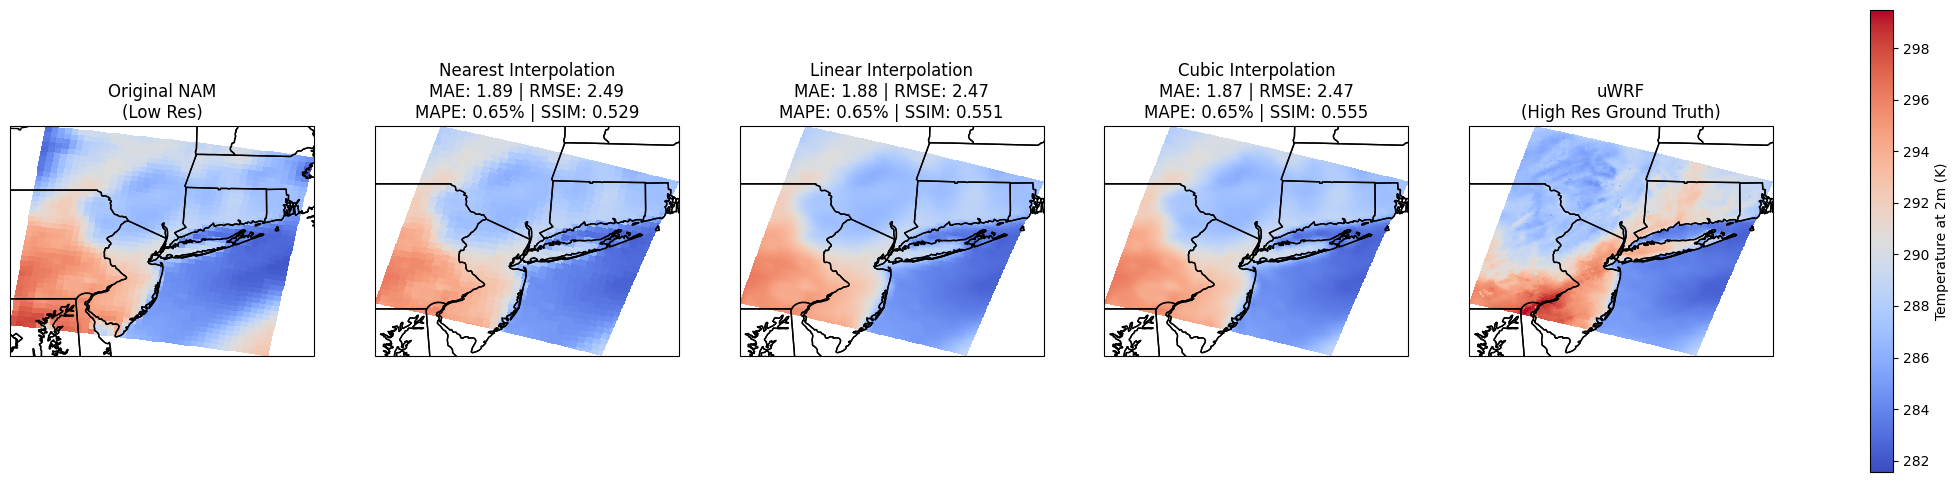

In [9]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

n_methods = len(results)
n_cols = n_methods + 2 # 2 bc we have nam and uwrf data to plot as well
fig, axes = plt.subplots(1, n_cols, figsize=(5 * n_cols, 6), subplot_kw={'projection': ccrs.PlateCarree()})

# Common color limits for consistency
vmin = min(lr.min(), hr.min())
vmax = max(lr.max(), hr.max())

# Plot original low-res NAM 
axes[0].pcolormesh(nam_lon, nam_lat, lr, cmap='coolwarm', vmin=vmin, vmax=vmax, transform=ccrs.PlateCarree())
axes[0].set_title("Original NAM\n(Low Res)")
axes[0].coastlines()
axes[0].add_feature(cfeature.STATES)

# Plot interpolated results
for i, (method, metrics) in enumerate(results.items(), start=1):
    ax = axes[i]
    ax.pcolormesh(uwrf_lon, uwrf_lat, metrics['interpolated'], cmap='coolwarm', vmin=vmin, vmax=vmax, transform=ccrs.PlateCarree())
    ax.set_title(
    f"{method.title()} Interpolation\n"
    f"MAE: {metrics['mae']:.2f} | RMSE: {metrics['rmse']:.2f}\n"
    f"MAPE: {metrics['mape']:.2f}% | SSIM: {metrics['ssim']:.3f}")
    ax.coastlines()
    ax.add_feature(cfeature.STATES)

# Plot ground truth uWRF
axes[-1].pcolormesh(uwrf_lon, uwrf_lat, hr, cmap='coolwarm', vmin=vmin, vmax=vmax, transform=ccrs.PlateCarree())
axes[-1].set_title("uWRF\n(High Res Ground Truth)")
axes[-1].coastlines()
axes[-1].add_feature(cfeature.STATES)

cbar = fig.colorbar(axes[-1].collections[0], ax=axes, orientation='vertical', fraction=0.04, pad=0.05)
cbar.set_label('Temperature at 2m (K)')

plt.show()


In [20]:
import pandas as pd
import numpy as np
import xarray as xr
from skimage.metrics import structural_similarity as ssim
from scipy.interpolate import griddata

# Config
var = 'T2' #CHANGEEEEEEE
num_timesteps = 577
interp_methods = ['nearest', 'linear', 'cubic']
records = []
downscaled = xr.open_dataarray('/home/gvaillant1/downscaled_T2.nc')


# -- Load Data ---
nam = xr.open_dataset('/D4/data/gvaillant/nam-split/nam_test.nc')
uwrf = xr.open_dataset('/D4/data/gvaillant/uwrf-split/uwrf_test.nc')

# Extract static lat/lon from NAM (assuming NAM grid is static)
nam_lat = nam['latitude'].values
nam_lon = nam['longitude'].values

for t_idx in range(num_timesteps):

    # --- Extract data for this time step ---
    lr = nam[var].isel(time=t_idx).values
    hr = uwrf[var].isel(time=t_idx).values
    uwrf_lat = uwrf['latitude'].isel(time=t_idx).values
    uwrf_lon = uwrf['longitude'].isel(time=t_idx).values

    hr_safe = np.where(np.abs(hr) < 1e-3, 1e-3, hr)
    hr_norm = (hr - hr.min()) / (hr.max() - hr.min())

    nam_points = np.column_stack((nam_lat.flatten(), nam_lon.flatten()))
    nam_values = lr.flatten()
    target_points = np.column_stack((uwrf_lat.flatten(), uwrf_lon.flatten()))

    # --- Interpolation methods ---
    for method in interp_methods:
        try:
            interp_flat = griddata(nam_points, nam_values, target_points, method=method)
            pred = interp_flat.reshape(hr.shape)
            pred_norm = (pred - hr.min()) / (hr.max() - hr.min())

            mae = np.mean(np.abs(pred - hr))
            rmse = np.sqrt(np.mean((pred - hr) ** 2))
            mape = np.mean(np.abs((pred - hr) / hr_safe)) * 100
            ssim_val = ssim(hr_norm, pred_norm, data_range=1.0)

            records.append({
                'method': method,
                'time': t_idx,
                'rmse': rmse,
                'mae': mae,
                'mape': mape,
                'ssim': ssim_val
            })

        except Exception as e:
            print(f"[{method}] failed at time {t_idx}: {e}")

    # --- ML-based downscaling (outside interpolation loop) ---
    try:
        ml_pred = downscaled.isel(time=t_idx).values
        ml_norm = (ml_pred - hr.min()) / (hr.max() - hr.min())

        mae = np.mean(np.abs(ml_pred - hr))
        rmse = np.sqrt(np.mean((ml_pred - hr) ** 2))
        mape = np.mean(np.abs((ml_pred - hr) / hr_safe)) * 100
        ssim_val = ssim(hr_norm, ml_norm, data_range=1.0)

        records.append({
            'method': 'ml',
            'time': t_idx,
            'rmse': rmse,
            'mae': mae,
            'mape': mape,
            'ssim': ssim_val
        })
    except Exception as e:
        print(f"[ml] failed at time {t_idx}: {e}")


# Final DataFrame
print(pd.DataFrame(records)['method'].value_counts())

df = pd.DataFrame(records)



method
nearest    577
linear     577
cubic      577
ml         577
Name: count, dtype: int64


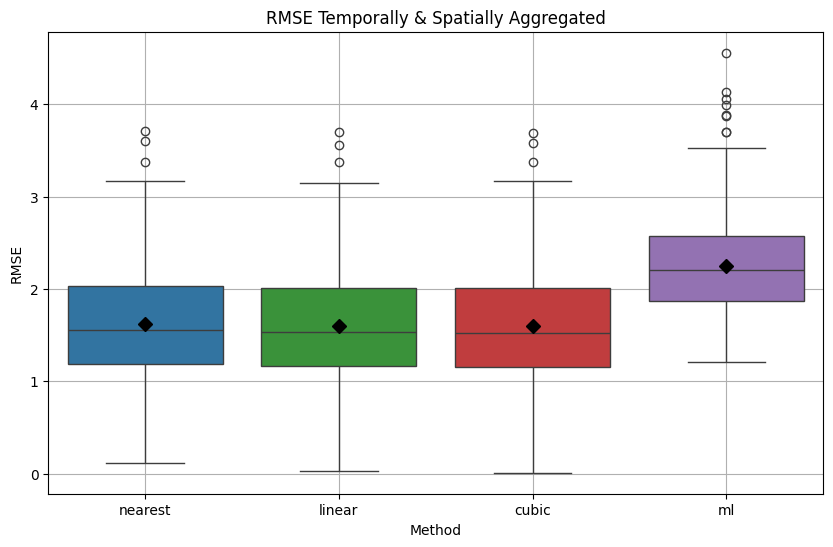

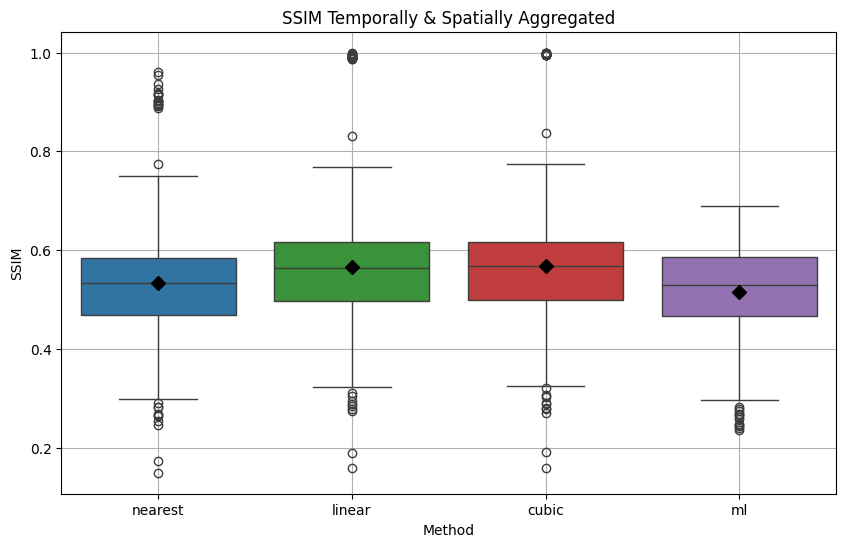

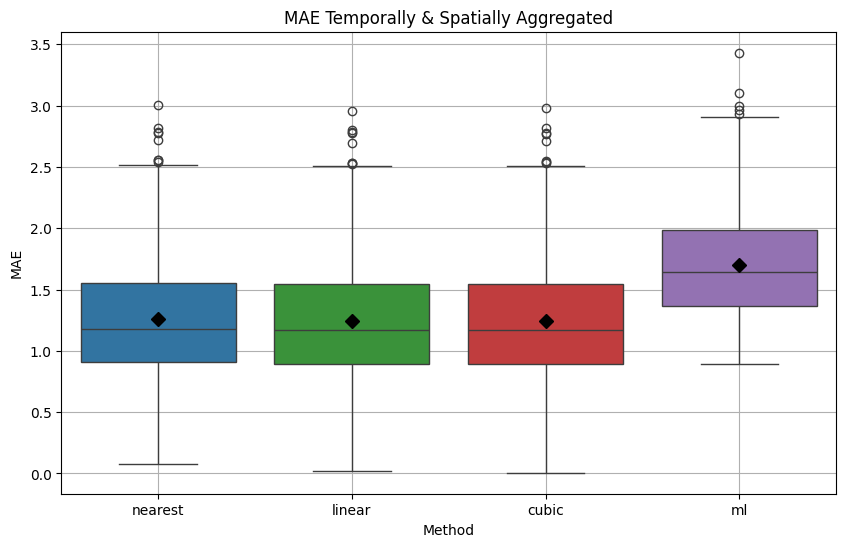

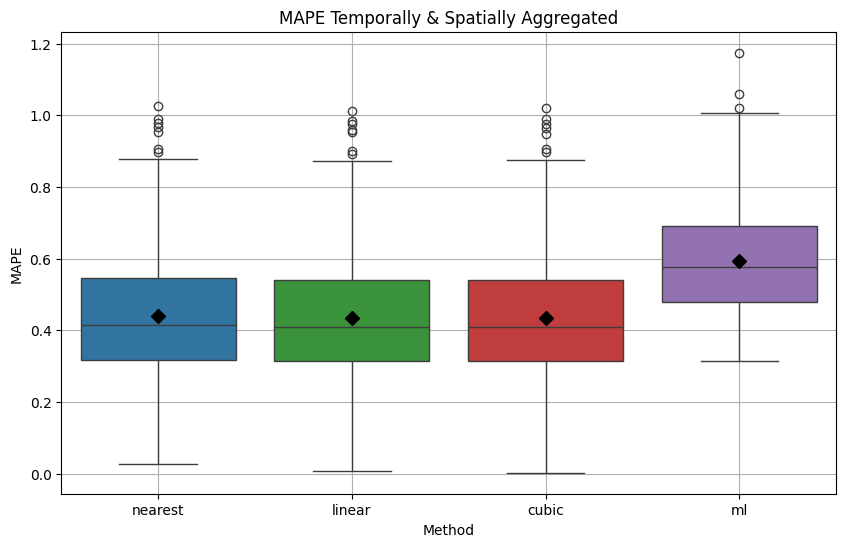

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

custom_palette = {
    'nearest': '#1f77b4',  # blue
    'linear':  '#2ca02c',  # green
    'cubic':   '#d62728',  # red
    'ml':      '#9467bd',  # purple
}

meanprops = {
    'marker': 'D',
    'markerfacecolor': 'black',
    'markeredgecolor': 'black',
    'markersize': 7
}

# RMSE plot
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df, x='method', y='rmse',
    palette=custom_palette,
    showmeans=True,
    meanprops=meanprops
)
plt.title("RMSE Temporally & Spatially Aggregated")
plt.ylabel("RMSE")
plt.xlabel("Method")
plt.grid(True)
plt.show()

# SSIM plot
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df, x='method', y='ssim',
    palette=custom_palette,
    showmeans=True,
    meanprops=meanprops
)
plt.title("SSIM Temporally & Spatially Aggregated")
plt.ylabel("SSIM")
plt.xlabel("Method")
plt.grid(True)
plt.show()

# MAE plot
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df, x='method', y='mae',
    palette=custom_palette,
    showmeans=True,
    meanprops=meanprops
)
plt.title("MAE Temporally & Spatially Aggregated")
plt.ylabel("MAE")
plt.xlabel("Method")
plt.grid(True)
plt.show()

# MAPE plot
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df, x='method', y='mape',
    palette=custom_palette,
    showmeans=True,
    meanprops=meanprops
)
plt.title("MAPE Temporally & Spatially Aggregated")
plt.ylabel("MAPE")
plt.xlabel("Method")
plt.grid(True)
plt.show()